# Kolmogorov-Smirnov Test | Anomaly Detection

Applies the two-sample KS test on **PCA-reduced embeddings (50 dims)** to detect stylistic anomalies.

Unlike Wasserstein (one distance per comparison) and Cosine (one score per painting), KS operates **per dimension** - giving a D statistic and p-value for each of the 50 PCA components. This makes it the most interpretable method: you can see *which* style dimensions deviate.

**Multiple testing correction:** Running 50 KS tests per comparison inflates false positives. Benjamini-Hochberg FDR correction is applied throughout.

Two phases:
- **Phase 1:** Artist vs Global: which artists deviate most from the Impressionism distribution?
- **Phase 2:** Per-painting: for each painting, compare its KNN neighbourhood to the global distribution

**Prerequisite:** Run `src/reduce_embeddings.py` once before this notebook.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIGURATION                                               ║
# ║  Change these two lines to run on a different genre or dataset.      ║
# ║  Use 'clean' for exploration, 'injected' for AUC-ROC evaluation.     ║
# ╚══════════════════════════════════════════════════════════════════════╝
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))
from config import (
    MIN_ARTIST_IMAGES, KNN_K, CONTAMINATION,
    genre_dataset_dir, genre_results_dir,
)

GENRE        = 'impressionism'          # label used in plot titles and result filenames
DATASET_TYPE = 'injected'               # 'clean' or 'injected'

EMBEDDINGS_DIR = genre_dataset_dir(GENRE, DATASET_TYPE)
METADATA_PATH  = EMBEDDINGS_DIR / 'metadata.csv'
PCA_EMB_PATH   = EMBEDDINGS_DIR / 'embeddings_pca50.npy'   # 50-dim PCA (used by KS test)
RESULTS_DIR    = genre_results_dir(GENRE, DATASET_TYPE)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Genre        : {GENRE}')
print(f'Dataset type : {DATASET_TYPE}')
print(f'Embeddings   : {PCA_EMB_PATH}')
print(f'Results dir  : {RESULTS_DIR}')

Genre        : impressionism
Dataset type : injected
Embeddings   : ..\embeddings\impressionism\injected\embeddings_pca50.npy
Results dir  : ..\results\impressionism\injected


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import ks_2samp
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

# Load — paths come from config cell above
if not PCA_EMB_PATH.exists():
    raise FileNotFoundError(f'PCA embeddings not found: {PCA_EMB_PATH}\n'
                            'Run: python src/reduce_embeddings.py --output_dir embeddings/clean')

embeddings_pca = np.load(PCA_EMB_PATH)
metadata       = pd.read_csv(METADATA_PATH).reset_index(drop=True)

N_DIMS = embeddings_pca.shape[1]
print('PCA embeddings shape :', embeddings_pca.shape)
print('Metadata shape       :', metadata.shape)
print('PCA dimensions       :', N_DIMS)
if 'is_anomaly' in metadata.columns:
    print('Known anomalies      :', metadata['is_anomaly'].sum())

PCA embeddings shape : (1575, 50)
Metadata shape       : (1575, 14)
PCA dimensions       : 50
Known anomalies      : 75


## Helper: Benjamini-Hochberg FDR Correction

Controls the false discovery rate when running 50 KS tests simultaneously (one per PCA dim).
Returns a boolean array: `True` = this dimension's difference is statistically significant.

In [67]:
def bh_correction(p_values, alpha=0.05):
    """Benjamini-Hochberg FDR correction.
    Returns boolean array: True = reject null (significant difference).
    """
    p = np.asarray(p_values)
    n = len(p)
    sorted_idx = np.argsort(p)
    sorted_p   = p[sorted_idx]
    thresholds = (np.arange(1, n + 1) / n) * alpha
    below      = sorted_p <= thresholds

    if below.any():
        cutoff = np.where(below)[0][-1]
        below[:cutoff + 1] = True

    reject = np.zeros(n, dtype=bool)
    reject[sorted_idx] = below
    return reject


def ks_score(X, Y, alpha=0.05):
    """Run KS test on each dimension between X and Y.
    Returns:
        d_stats  : D statistic per dim (shape: n_dims)
        p_values : p-value per dim    (shape: n_dims)
        reject   : BH-corrected significance mask (shape: n_dims)
        mean_d   : mean D across all dims (primary anomaly score)
        n_sig    : number of significantly different dims after BH correction
    """
    n_dims   = X.shape[1]
    d_stats  = np.zeros(n_dims)
    p_values = np.zeros(n_dims)

    for dim in range(n_dims):
        d_stats[dim], p_values[dim] = ks_2samp(X[:, dim], Y[:, dim])

    reject = bh_correction(p_values, alpha=alpha)
    mean_d = d_stats.mean()
    n_sig  = reject.sum()
    return d_stats, p_values, reject, mean_d, n_sig


print('Helpers ready.')

Helpers ready.


## Phase 1: Artist vs Global Distribution

For each qualified artist (≥ 20 images), we compare their embedding distribution to the full 1,500-painting Impressionism distribution across all 50 PCA dimensions.

Artists with high mean D and many significant dimensions sit stylistically far from the genre centre.

In [ ]:
artist_counts     = metadata['artist'].value_counts()
qualified_artists = artist_counts[artist_counts >= MIN_ARTIST_IMAGES].index.tolist()
print(f'Qualified artists: {len(qualified_artists)}')

artist_results = {}
artist_d_matrix = {}  # per-dim D stats for heatmap

for artist in tqdm(qualified_artists, desc='Artist vs Global KS'):
    idx         = metadata[metadata['artist'] == artist].index.tolist()
    artist_emb  = embeddings_pca[idx]
    d_stats, p_values, reject, mean_d, n_sig = ks_score(artist_emb, embeddings_pca)

    artist_results[artist] = {
        'mean_d'   : mean_d,
        'max_d'    : d_stats.max(),
        'n_sig_dims': n_sig,
        'n_images' : len(idx)
    }
    artist_d_matrix[artist] = d_stats

artist_df = (
    pd.DataFrame(artist_results).T
    .reset_index()
    .rename(columns={'index': 'artist'})
    .sort_values('mean_d', ascending=False)
    .reset_index(drop=True)
)
print(artist_df.to_string(index=False))

Qualified artists: 14


Artist vs Global KS: 100%|██████████| 14/14 [00:00<00:00, 51.27it/s]

               artist   mean_d    max_d  n_sig_dims  n_images
  gustave caillebotte 0.212824 0.423571         3.0      24.0
         mary cassatt 0.212524 0.657143         6.0      28.0
       berthe morisot 0.206473 0.498126         6.0      31.0
        eugene boudin 0.203093 0.566188        24.0      59.0
     joaquã­n sorolla 0.200926 0.560928        11.0      39.0
  john singer sargent 0.191885 0.506263         6.0      33.0
   konstantin korovin 0.181340 0.348718         0.0      26.0
          edgar degas 0.168192 0.517153        14.0      64.0
william merritt chase 0.161953 0.381011         5.0      43.0
        alfred sisley 0.158636 0.601101        14.0      64.0
        childe hassam 0.152994 0.271477        12.0      59.0
     camille pissarro 0.137765 0.321074        11.0      91.0
pierre auguste renoir 0.129709 0.406118        22.0     165.0
         claude monet 0.093358 0.408438        11.0     169.0


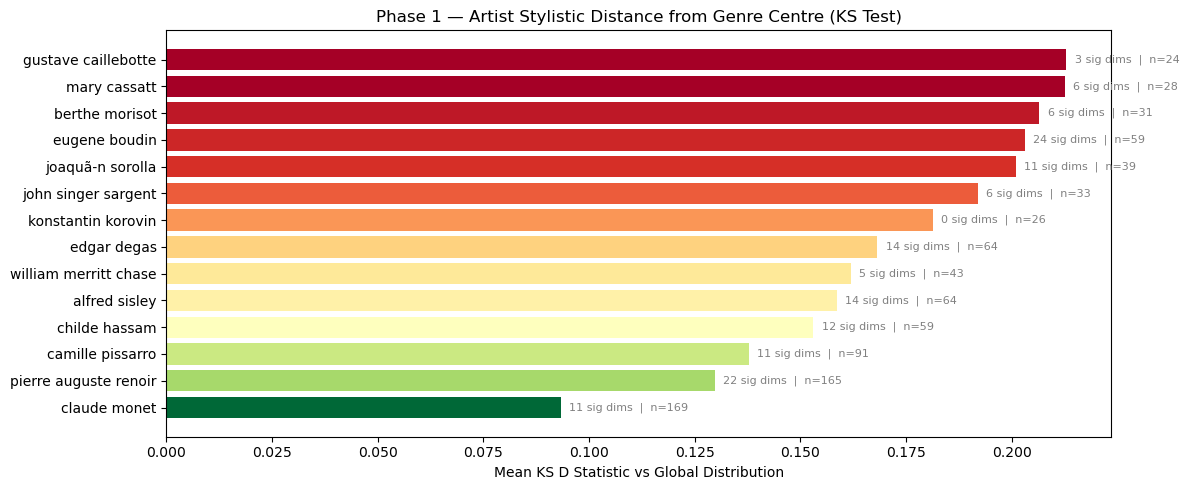

In [69]:
# Bar chart: mean D per artist
fig, ax = plt.subplots(figsize=(12, 5))
norm_vals = (artist_df['mean_d'] - artist_df['mean_d'].min()) / \
            (artist_df['mean_d'].max() - artist_df['mean_d'].min())
colors = plt.cm.RdYlGn_r(norm_vals)

bars = ax.barh(artist_df['artist'], artist_df['mean_d'], color=colors)
ax.set_xlabel('Mean KS D Statistic vs Global Distribution')
ax.set_title('Phase 1 — Artist Stylistic Distance from Genre Centre (KS Test)')
ax.invert_yaxis()

for bar, n_sig, n_img in zip(bars, artist_df['n_sig_dims'], artist_df['n_images']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{int(n_sig)} sig dims  |  n={int(n_img)}',
            va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ks_phase1_artist_mean_d.png', dpi=150)
plt.show()

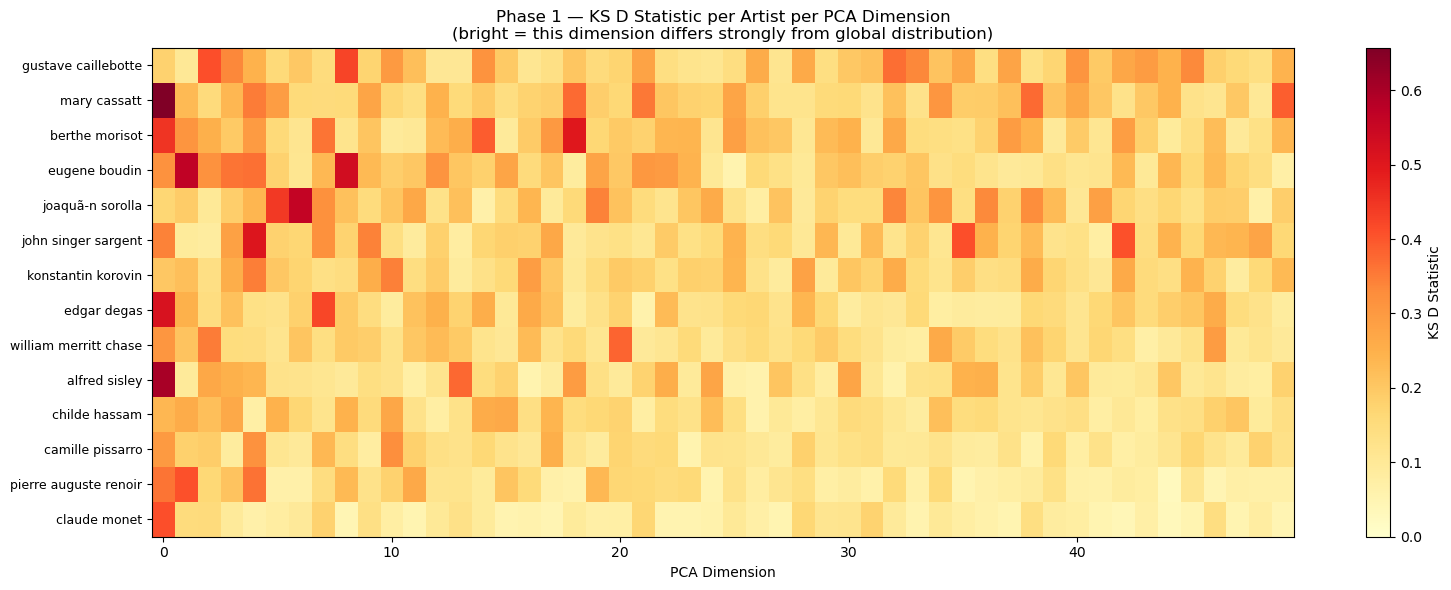

In [70]:
# Heatmap: D statistic per artist per PCA dimension
d_matrix = np.array([artist_d_matrix[a] for a in artist_df['artist']])

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(d_matrix, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=d_matrix.max())
plt.colorbar(im, ax=ax, label='KS D Statistic')
ax.set_yticks(range(len(artist_df)))
ax.set_yticklabels(artist_df['artist'], fontsize=9)
ax.set_xlabel('PCA Dimension')
ax.set_title('Phase 1 — KS D Statistic per Artist per PCA Dimension\n'
             '(bright = this dimension differs strongly from global distribution)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ks_phase1_artist_dim_heatmap.png', dpi=150)
plt.show()

In [71]:
# Save Phase 1
artist_df.to_csv(RESULTS_DIR / 'ks_phase1_artist_scores.csv', index=False)
print('Saved - results/ks_phase1_artist_scores.csv')

Saved - results/ks_phase1_artist_scores.csv


## Phase 2: Per-Painting Anomaly Score (KNN Neighbourhood vs Global)

For each painting, compare the distribution of its K=20 nearest neighbours against the global distribution across all 50 PCA dimensions.

Primary score: **mean D across all 50 dims**  
Secondary score: **number of significantly different dims** after BH correction

In [ ]:
nn = NearestNeighbors(n_neighbors=KNN_K + 1, metric='cosine', n_jobs=-1)
nn.fit(embeddings_pca)
_, knn_indices = nn.kneighbors(embeddings_pca)
knn_indices = knn_indices[:, 1:]  # exclude self

print(f'KNN index built (K={KNN_K}).')

KNN index built (K=20).


In [73]:
painting_mean_d  = np.zeros(len(metadata))
painting_n_sig   = np.zeros(len(metadata), dtype=int)

for i in tqdm(range(len(metadata)), desc='Per-painting KS'):
    neighbourhood = embeddings_pca[knn_indices[i]]
    _, _, _, mean_d, n_sig = ks_score(neighbourhood, embeddings_pca)
    painting_mean_d[i] = mean_d
    painting_n_sig[i]  = n_sig

metadata['ks_mean_d']  = painting_mean_d
metadata['ks_n_sig']   = painting_n_sig

print(f'Mean D  : {painting_mean_d.mean():.4f}')
print(f'Std     : {painting_mean_d.std():.4f}')
print(f'Min     : {painting_mean_d.min():.4f}')
print(f'Max     : {painting_mean_d.max():.4f}')

Per-painting KS: 100%|██████████| 1575/1575 [00:30<00:00, 51.96it/s]

Mean D  : 0.2985
Std     : 0.0323
Min     : 0.2291
Max     : 0.4222


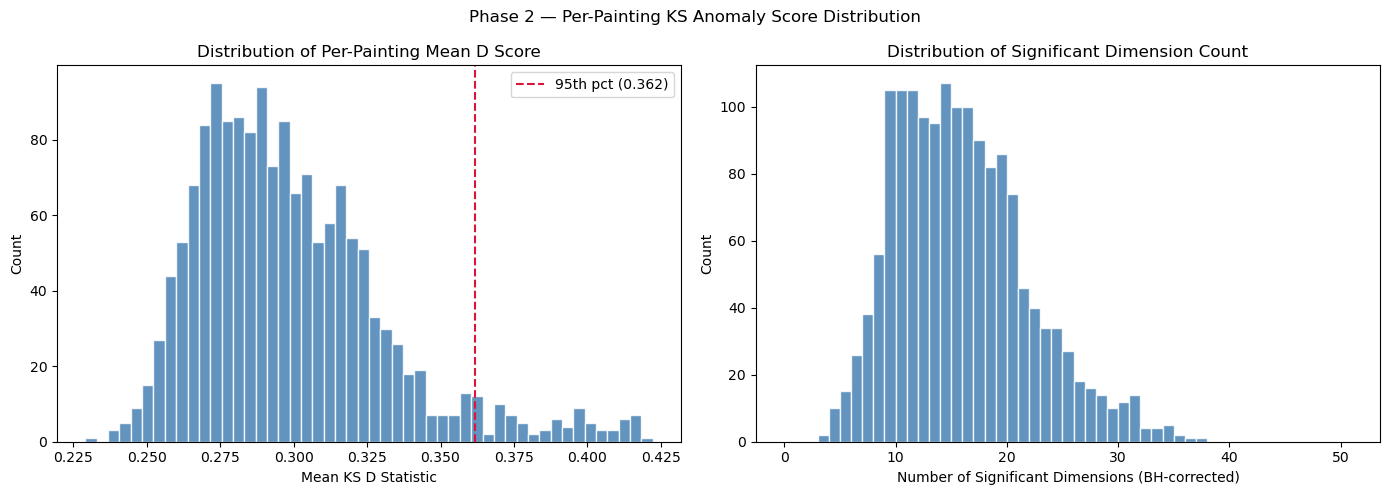

Flagged (top 5%): 79 paintings


In [74]:
# Histogram: mean D distribution with threshold
threshold = np.percentile(painting_mean_d, 95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(painting_mean_d, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(threshold, color='crimson', linestyle='--', linewidth=1.5,
                label=f'95th pct ({threshold:.3f})')
axes[0].set_xlabel('Mean KS D Statistic')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Per-Painting Mean D Score')
axes[0].legend()

# Significant dimensions count
axes[1].hist(painting_n_sig, bins=range(0, N_DIMS + 2), color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Number of Significant Dimensions (BH-corrected)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Significant Dimension Count')

plt.suptitle('Phase 2 — Per-Painting KS Anomaly Score Distribution', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ks_phase2_painting_histogram.png', dpi=150)
plt.show()
print(f'Flagged (top 5%): {(painting_mean_d >= threshold).sum()} paintings')

c:\Users\Yeva\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


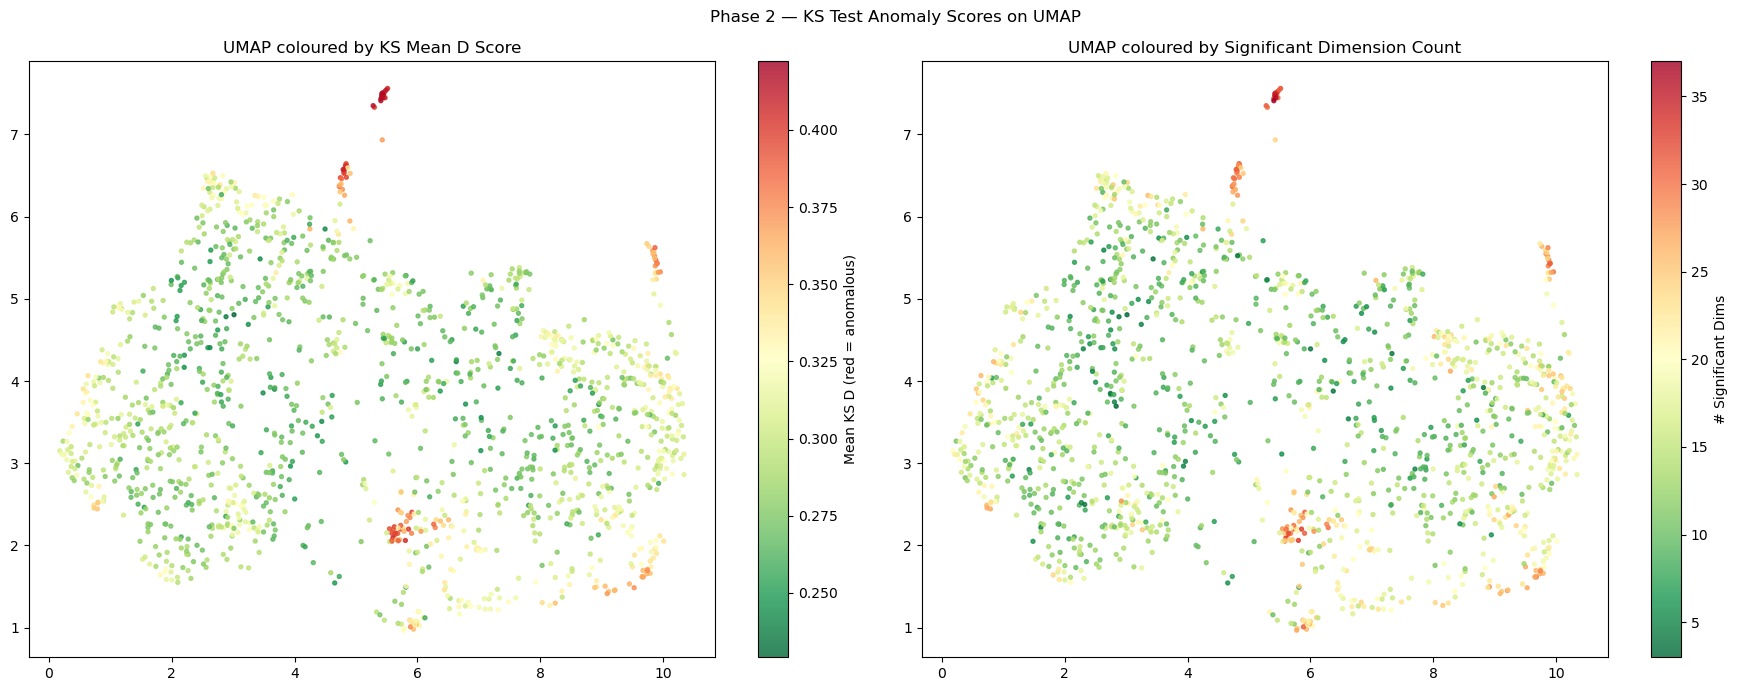

In [75]:
# UMAP coloured by KS anomaly score 
try:
    import umap
except ImportError:
    raise ImportError('Install umap-learn: pip install umap-learn')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords  = reducer.fit_transform(embeddings_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(coords[:, 0], coords[:, 1],
                     c=painting_mean_d, cmap='RdYlGn_r', s=8, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='Mean KS D (red = anomalous)')
axes[0].set_title('UMAP coloured by KS Mean D Score')

# Significant dimensions count
sc2 = axes[1].scatter(coords[:, 0], coords[:, 1],
                      c=painting_n_sig, cmap='RdYlGn_r', s=8, alpha=0.8)
plt.colorbar(sc2, ax=axes[1], label='# Significant Dims')
axes[1].set_title('UMAP coloured by Significant Dimension Count')

plt.suptitle('Phase 2 — KS Test Anomaly Scores on UMAP', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ks_phase2_umap.png', dpi=150)
plt.show()

In [76]:
# Top 20 anomalies by mean D 
top_anomalies = (
    metadata[['filename', 'artist', 'ks_mean_d', 'ks_n_sig']]
    .sort_values('ks_mean_d', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
print('Top 20 anomalies by KS mean D:')
top_anomalies.style.background_gradient(subset=['ks_mean_d', 'ks_n_sig'], cmap='Reds')

Top 20 anomalies by KS mean D:


,filename,artist,ks_mean_d,ks_n_sig
0,Impressionism/antoine-blanchard_arc-de-triomphe-4.jpg,antoine blanchard,0.422229,35
1,Impressionism/antoine-blanchard_arc-de-triomphe-2.jpg,antoine blanchard,0.417987,34
2,Impressionism/antoine-blanchard_gare-de-lest-2.jpg,antoine blanchard,0.417952,35
3,Impressionism/antoine-blanchard_la-gare-dorleans-et-le-quai-dorsay.jpg,antoine blanchard,0.417289,37
4,Impressionism/antoine-blanchard_caf-de-la-paix-2.jpg,antoine blanchard,0.414981,36
5,Impressionism/antoine-blanchard_boulevard-de-la-madeleine-7.jpg,antoine blanchard,0.414889,33
6,Impressionism/antoine-blanchard_place-de-la-madeleine.jpg,antoine blanchard,0.414851,34
7,Impressionism/marianne-north_the-street-of-blood-delhi-1880.jpg,marianne north,0.414641,31
8,Impressionism/antoine-blanchard_boulevard-de-la-madeleine-2.jpg,antoine blanchard,0.413289,30
9,Impressionism/antoine-blanchard_rue-royal-madeleine-2.jpg,antoine blanchard,0.413143,32


In [77]:
# Save Phase 2
metadata[['filename', 'artist', 'ks_mean_d', 'ks_n_sig']].to_csv(
    RESULTS_DIR / 'ks_phase2_painting_scores.csv', index=False
)
print('Saved - results/ks_phase2_painting_scores.csv')

Saved - results/ks_phase2_painting_scores.csv


## Cross-Method Comparison: Cosine, Wasserstein, KS

Paintings flagged by all three methods are the strongest anomaly candidates.
Paintings flagged by only one method may reflect that method's specific sensitivity.

In [78]:
cosine_path = RESULTS_DIR / 'phase1_global_cosine_scores.csv'
swd_path    = RESULTS_DIR / 'wasserstein_phase2_painting_scores.csv'

missing = [p for p in [cosine_path, swd_path] if not p.exists()]
if missing:
    print('Missing result files — run the following notebooks first:')
    for p in missing:
        print(f'  {p.name}')
else:
    cosine_df = pd.read_csv(cosine_path)[['filename', 'global_anomaly_score']]
    swd_df    = pd.read_csv(swd_path)[['filename', 'painting_swd_norm']]
    ks_df     = metadata[['filename', 'artist', 'ks_mean_d']]

    # normalize KS score 0-1
    ks_df = ks_df.copy()
    ks_df['ks_mean_d_norm'] = (
        (ks_df['ks_mean_d'] - ks_df['ks_mean_d'].min()) /
        (ks_df['ks_mean_d'].max() - ks_df['ks_mean_d'].min())
    )

    all_scores = (
        ks_df
        .merge(cosine_df, on='filename', how='inner')
        .merge(swd_df,    on='filename', how='inner')
    )

    # top 5% on each method
    c_thresh  = np.percentile(all_scores['global_anomaly_score'], 95)
    w_thresh  = np.percentile(all_scores['painting_swd_norm'],    95)
    ks_thresh = np.percentile(all_scores['ks_mean_d_norm'],       95)

    all_scores['flagged_cosine'] = all_scores['global_anomaly_score'] >= c_thresh
    all_scores['flagged_swd']    = all_scores['painting_swd_norm']    >= w_thresh
    all_scores['flagged_ks']     = all_scores['ks_mean_d_norm']       >= ks_thresh
    all_scores['n_methods']      = (
        all_scores['flagged_cosine'].astype(int) +
        all_scores['flagged_swd'].astype(int) +
        all_scores['flagged_ks'].astype(int)
    )

    print('Flagged by N methods:')
    print(all_scores['n_methods'].value_counts().sort_index().to_string())

Flagged by N methods:
n_methods
0    1391
1     133
2      49
3       2


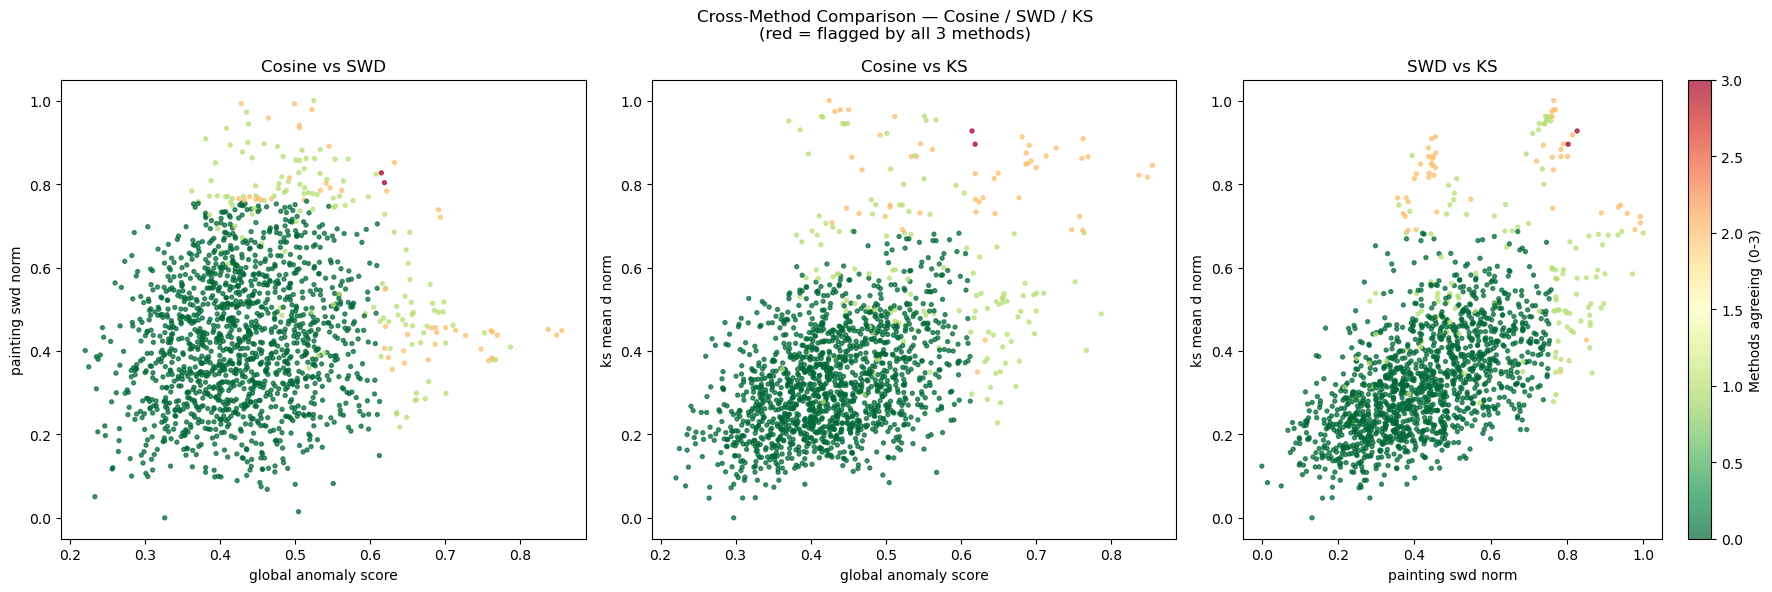

Flagged by ALL 3 methods (2 paintings):
                                                  filename        artist  global_anomaly_score  painting_swd_norm  ks_mean_d_norm
Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg  claude monet              0.614898           0.826847        0.927213
     Impressionism/eugene-boudin_the-port-at-deauville.jpg eugene boudin              0.619024           0.803344        0.895455

Flagged by KS + Cosine only (27 paintings):
                                                                                 filename                  artist  ks_mean_d_norm  global_anomaly_score  painting_swd_norm
                                Expressionism/paul-klee_in-the-style-of-kairouan-1914.jpg               paul klee        0.913076              0.681586           0.455326
                                               Cubism/rene-magritte_landscape-1920(1).jpg           rene magritte        0.908704              0.762850           0.445276
            

In [79]:
if 'all_scores' in dir():
    # pairwise method comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    pairs = [
        ('global_anomaly_score', 'painting_swd_norm',  'Cosine vs SWD'),
        ('global_anomaly_score', 'ks_mean_d_norm',     'Cosine vs KS'),
        ('painting_swd_norm',    'ks_mean_d_norm',     'SWD vs KS'),
    ]
    for ax, (x_col, y_col, title) in zip(axes, pairs):
        c = all_scores['n_methods']
        sc = ax.scatter(all_scores[x_col], all_scores[y_col],
                        c=c, cmap='RdYlGn_r', vmin=0, vmax=3,
                        s=8, alpha=0.7)
        ax.set_xlabel(x_col.replace('_', ' '))
        ax.set_ylabel(y_col.replace('_', ' '))
        ax.set_title(title)

    plt.colorbar(sc, ax=axes[-1], label='Methods agreeing (0-3)')
    plt.suptitle('Cross-Method Comparison — Cosine / SWD / KS\n'
                 '(red = flagged by all 3 methods)', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cross_method_all_three.png', dpi=150)
    plt.show()

    # Flagged by ALL 3 
    consensus = (
        all_scores[all_scores['n_methods'] == 3]
        [['filename', 'artist', 'global_anomaly_score', 'painting_swd_norm', 'ks_mean_d_norm']]
        .sort_values('ks_mean_d_norm', ascending=False)
        .reset_index(drop=True)
    )
    print(f'Flagged by ALL 3 methods ({len(consensus)} paintings):')
    print(consensus.to_string(index=False))

    # Flagged by KS + Cosine only
    ks_cosine = (
        all_scores[all_scores['flagged_ks'] & all_scores['flagged_cosine'] & ~all_scores['flagged_swd']]
        [['filename', 'artist', 'ks_mean_d_norm', 'global_anomaly_score', 'painting_swd_norm']]
        .sort_values('ks_mean_d_norm', ascending=False)
        .reset_index(drop=True)
    )
    print(f'\nFlagged by KS + Cosine only ({len(ks_cosine)} paintings):')
    print(ks_cosine.to_string(index=False))

    # Flagged by KS + Wasserstein only 
    ks_swd = (
        all_scores[all_scores['flagged_ks'] & all_scores['flagged_swd'] & ~all_scores['flagged_cosine']]
        [['filename', 'artist', 'ks_mean_d_norm', 'painting_swd_norm', 'global_anomaly_score']]
        .sort_values('ks_mean_d_norm', ascending=False)
        .reset_index(drop=True)
    )
    print(f'\nFlagged by KS + Wasserstein only ({len(ks_swd)} paintings):')
    print(ks_swd.to_string(index=False))

In [80]:
if 'all_scores' in dir():
    all_scores.to_csv(RESULTS_DIR / 'cross_method_all_scores.csv', index=False)
    print('Saved - results/cross_method_all_scores.csv')

Saved - results/cross_method_all_scores.csv
